In [1]:
import json
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import dataset_utils

from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering

from datasets.mvtec_dataset import MVTecDataset
from moviad.utilities.configurations import TaskType, Split, LabelName
from ollama import Client

In [2]:
client = Client(host="http://localhost:6000")
os.environ["CUDA_VISIBLE_DEVICES"] = ""
MODEL_NAME = "gemma3:12b"
categories = ["hazelnut", "screw", "carpet"]
dataset_path = "/mnt/disk1/borsattifr/datasets/mvtec"

## Create concept list

In [ ]:
for category in categories:

    concepts = set()

    train_dataset = MVTecDataset(task = TaskType.SEGMENTATION, root = dataset_path, category = category, split = "train")
    train_dataset.load_dataset()

    test_dataset = MVTecDataset(task = TaskType.SEGMENTATION, root = dataset_path, category = category, split = "test")
    test_dataset.load_dataset()

    anomalous_samples = test_dataset.samples[test_dataset.samples.label_index == LabelName.ABNORMAL]
    print(f"Number of anomalous images: {len(anomalous_samples)}")

    normal_test_samples = test_dataset.samples[test_dataset.samples.label_index == LabelName.NORMAL]
    normal_samples = pd.concat([train_dataset.samples, normal_test_samples])
    print(f"Number of normal images: {len(normal_samples)}")

    for i in range(len(normal_samples)):
        sample = normal_samples.iloc[i]
        concept_json = dataset_utils.first_vlm_query(category, MODEL_NAME, sample, anomalous = False)
        concepts.update(c.lower() for c in concept_json)
        
    
    for i in range(len(anomalous_samples)):
        sample = anomalous_samples.iloc[i]
        concept_json = dataset_utils.first_vlm_query(category, MODEL_NAME, sample, anomalous = True)
        concepts.update(c.lower() for c in concept_json)

    concepts = list(concepts)
    
    with open(f"{category}_concepts.json", "w") as f:
        json.dump(concepts, f)


## Inspect list

In [5]:
def number_of_concepts(category):
    path = f"concept_lists/original/{category}_concepts.json"
    with open(path, "r") as f:
        concepts = json.load(f)
    print(f"Original number of concepts for {category}:", len(concepts))
    return concepts

In [6]:
hazelnut_concepts = number_of_concepts("hazelnut")
carpet_concepts = number_of_concepts("carpet")
screw_concepts = number_of_concepts("screw")


Original number of concepts for hazelnut: 149
Original number of concepts for carpet: 161
Original number of concepts for screw: 229


### First step: cluster together similar words and retain only one of them

In [8]:
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(screw_concepts)

clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=0.5, linkage="average")
labels = clustering.fit_predict(embeddings)

In [9]:
from collections import defaultdict

grouped = defaultdict(list)
for concept, label in zip(screw_concepts, labels):
    grouped[label].append(concept)

grouped_concepts = list(grouped.values())

print(grouped_concepts)

[['scratched metal'], ['bent shaft'], ['head marking'], ['thread apex rounding'], ['hexagonal head'], ['visible abrasion'], ['altered geometry'], ['deformed tip'], ['blunted top'], ['linear mark', 'linear marking'], ['missing ridges'], ['visible linear marks'], ['thread irregularity', 'thread irregularity', 'irregular thread', 'irregular_thread', 'irregular threads'], ['tapered tip'], ['countersunk head'], ['thread truncation', 'thread truncation'], ['conical head', 'cone-shaped head'], ['tapered body'], ['missing threads', 'missing thread', 'missing thread'], ['metal imperfection'], ['surface irregularity', 'irregular surface', 'surface irregularity', 'irregular surface'], ['neck deformation'], ['broken thread', 'broken_thread'], ['grey color', 'gray color'], ['rounded thread', 'rounded thread apex'], ['metal abrasion', 'metal abrasion'], ['flattened top', 'flattened top'], ['damaged threads', 'damaged_threads', 'damaged thread'], ['pointed tip'], ['flattened profile'], ['uniform text

In [10]:
filtered_concepts = []
for sublist in grouped_concepts:
    filtered_concepts.append(sublist[0])

print("Number of filtered concepts:", len(filtered_concepts))
print(filtered_concepts)

Number of filtered concepts: 181
['scratched metal', 'bent shaft', 'head marking', 'thread apex rounding', 'hexagonal head', 'visible abrasion', 'altered geometry', 'deformed tip', 'blunted top', 'linear mark', 'missing ridges', 'visible linear marks', 'thread irregularity', 'tapered tip', 'countersunk head', 'thread truncation', 'conical head', 'tapered body', 'missing threads', 'metal imperfection', 'surface irregularity', 'neck deformation', 'broken thread', 'grey color', 'rounded thread', 'metal abrasion', 'flattened top', 'damaged threads', 'pointed tip', 'flattened profile', 'uniform texture', 'spiral threads', 'head scratch', 'smooth surface', 'defined head', 'missing thread ridge', 'slightly reflective', 'distorted_head', 'blunted edge', 'neck scratch', 'irregular pitch', 'thread incomplete', 'localized abrasion', 'head surface damage', 'head blemish', 'cylindrical shape', 'tapered shank', 'visible cracks', 'head scratch marks', 'tapered head', 'visible ridges', 'mark present',

### Second step: query an LLM

In [39]:
message = "You are an industrial expert that is performing the task of visual anomaly detection."\
        f"Given the following list of visual concepts: {filtered_concepts}, related to images of a screw, please group together those that refer to the same LITERAL meaning, i.e. if they share key words, spelling..."\
        "Ignore semantic relationships, focus only on literal wording and string similarity."\
        "Moreover, choose a representative attribute that best summarizes the group."\
        "I provide two examples: 1. 'Elliptical shape': ['ellipsoidal shape', 'ellipsoid shape', 'elliptical shape']"\
        "2. 'Smooth texture': ['natural texture, 'smooth texture', 'smooth surface texture', 'smooth appearance', 'organic texture', 'uniform texture', 'consistent texture']"\
        "DO NOT create groups that are too general, e.g. grouping together all colours or all textures. Representative concepts should still be able to clearly discriminate between normal and anomalous images."\
        "Return the output as a JSON dictionary where each key is the representative concept, and its value is the list of similar concepts grouped with it."\
        "In case of concepts that cannot be grouped with any other concept, the dictionary should have both as key and value the concept itself."\
        "Please, output ONLY the JSON dictionary."

response = client.chat(model=MODEL_NAME, messages=[{"role": "user", "content": message}])

try:
    concept_json = dataset_utils.extract_json(response["message"]["content"])
except Exception as e:
    print(f"Error parsing response: {e}")
    concept_json = []

In [40]:
print(concept_json)

{'scratched surface': ['scratched metal', 'head scratch', 'neck scratch', 'visible scratch', 'head scratch marks', 'neck_scratching', 'surface scratch', 'visible scratch marks', 'scratch mark', 'visible lines'], 'thread truncation': ['thread truncation', 'thread incomplete', 'truncated threads', 'abrupt end', 'thread discontinuity', 'abrupt thread transition', 'thread_missing', 'thread_top_damage'], 'bent tip': ['bent shaft', 'deformed tip', 'blunted top', 'flattened top', 'blunted edge', 'flattened tip', 'damaged tip', 'bent tip', 'blunted tip'], 'thread irregularity': ['thread irregularity', 'thread inconsistency', 'uneven thread', 'spiral threads', 'thread flattening', 'thread profile irregularity', 'uneven thread pitch', 'irregular thread spacing', 'thread profile deviation', 'thread misalignment', 'thread angle deviation', 'irregular thread shape', 'irregular thread pattern', 'thread deformation', 'deformed threads', 'threaded shaft', 'blunt thread end'], 'metal abrasion': ['visib

In [41]:
print("Number of concepts extracted by the LLM:", len(concept_json))
print("Extracted concepts:", concept_json.keys())

Number of concepts extracted by the LLM: 25
Extracted concepts: dict_keys(['scratched surface', 'thread truncation', 'bent tip', 'thread irregularity', 'metal abrasion', 'head marking', 'altered geometry', 'tapered form', 'metallic appearance', 'defined head', 'surface imperfection', 'localized deformation', 'visible_markings', 'neck damage', 'cylindrical shape', 'uniform appearance', 'compressed form', 'unnatural rounding', 'rounded edges', 'missing ridges', 'discoloration present', 'smooth surface', 'visible lines', 'linear mark', 'slightly reflective'])


In [ ]:
with open("concept_lists/filtered/carpet_concepts.json", "w") as f:
    json.dump(concept_json, f)

In [8]:
with open("concept_lists/filtered/carpet_concepts.json", "r") as f:
    filtered_carpet_concepts = json.load(f)

print("Final number of concepts:", len(filtered_carpet_concepts))

final_carpet_concepts = list(filtered_carpet_concepts.keys())

Final number of concepts: 37


In [9]:
print(final_carpet_concepts)

['Hole', 'Torn Appearance', 'Dark Area', 'Color Variation', 'Fiber Protrusion', 'Missing Material', 'Woven Pattern', 'Metallic Sheen', 'Uneven Distribution', 'Void', 'Lighter Area', 'Irregular Shape', 'Unraveling', 'Foreign Object', 'Texture Disruption', 'Consistent Appearance', 'Exposed Backing', 'Chromatic Anomaly', 'Interwoven Structure', 'Looped Pile', 'Shadowed Area', 'Spotty Appearance', 'Rectangular Pattern', 'Fiber Strands', 'Visible Fibers', 'Fibrous Appearance', 'Detached Fiber', 'Damaged Fiber', 'Embedded Object', 'Brown Color', 'Reddish Hue', 'Neutral Color', 'Isolated Patch', 'Discoloration', 'Color Discontinuity', 'Pattern Disruption', 'Short Fibers']


## Final Dataset creation

### VLM prompting

In [15]:
category = "screw"
normal_images_concepts = []
anomalous_images_concepts = []

train_dataset = MVTecDataset(task = TaskType.SEGMENTATION, root = dataset_path, category = category, split = "train")
train_dataset.load_dataset()

test_dataset = MVTecDataset(task = TaskType.SEGMENTATION, root = dataset_path, category = category, split = "test")
test_dataset.load_dataset()

anomalous_samples = test_dataset.samples[test_dataset.samples.label_index == LabelName.ABNORMAL]
print(f"Number of anomalous images: {len(anomalous_samples)}")

normal_test_samples = test_dataset.samples[test_dataset.samples.label_index == LabelName.NORMAL]
normal_samples = pd.concat([train_dataset.samples, normal_test_samples])
print(f"Number of normal images: {len(normal_samples)}")

for i in range(len(normal_samples)):
    sample = normal_samples.iloc[i]
    concept_vector = dataset_utils.second_vlm_query(category, MODEL_NAME, sample, final_screw_concepts, anomalous = False)
    normal_images_concepts.append(concept_vector)
    print(f"Finished image {i}")

normal_concepts_df = pd.DataFrame(normal_images_concepts, columns = [f"{c}" for c in final_screw_concepts])
normal_samples = pd.concat([normal_samples.reset_index(drop=True), normal_concepts_df], axis = 1)
print("End of normal images") 

for i in range(len(anomalous_samples)):
    sample = anomalous_samples.iloc[i]
    concept_vector_anomalous = dataset_utils.second_vlm_query(category, MODEL_NAME, sample, final_screw_concepts, anomalous = True)
    anomalous_images_concepts.append(concept_vector_anomalous)

anomalous_concepts_df = pd.DataFrame(anomalous_images_concepts, columns = [f"{c}" for c in final_screw_concepts])
anomalous_samples = pd.concat([anomalous_samples.reset_index(drop=True), anomalous_concepts_df], axis = 1)

final_screw_df = pd.concat([normal_samples, anomalous_samples], ignore_index = True)

final_screw_df.to_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/screw_dataset.csv", index = False)

Number of anomalous images: 119
Number of normal images: 361
Finished image 0
Finished image 1
Finished image 2
Finished image 3
Finished image 4
Finished image 5
Finished image 6
Finished image 7
Finished image 8
Finished image 9
Finished image 10
Finished image 11
Finished image 12
Finished image 13
Finished image 14
Finished image 15
Finished image 16
Finished image 17
Finished image 18
Finished image 19
Finished image 20
Finished image 21
Finished image 22
Finished image 23
Finished image 24
Finished image 25
Finished image 26
Finished image 27
Finished image 28
Finished image 29
Finished image 30
Finished image 31
Finished image 32
Finished image 33
Finished image 34
Finished image 35
Finished image 36
Finished image 37
Finished image 38
Finished image 39
Finished image 40
Finished image 41
Finished image 42
Finished image 43
Finished image 44
Finished image 45
Finished image 46
Finished image 47
Finished image 48
Finished image 49
Finished image 50
Finished image 51
Finished imag

In [3]:
final_carpet_df = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/carpet_dataset.csv")

In [6]:
final_carpet_df

,path,split,label,image_path,label_index,mask_path,Hole,Dark Area,Color Variation,Fiber Protrusion,...,Rectangular Pattern,Detached Fiber,Damaged Fiber,Brown Color,Neutral Color,Isolated Patch,Discoloration,Color Discontinuity,Pattern Disruption,Short Fibers
0,/mnt/disk1/borsattifr/datasets/mvtec/carpet,train,good,/mnt/disk1/borsattifr/datasets/mvtec/carpet/tr...,0,NaN,0,0,0,1,...,1,1,0,0,1,0,0,0,0,0
1,/mnt/disk1/borsattifr/datasets/mvtec/carpet,train,good,/mnt/disk1/borsattifr/datasets/mvtec/carpet/tr...,0,NaN,0,0,0,1,...,1,0,0,0,1,0,1,1,0,1
2,/mnt/disk1/borsattifr/datasets/mvtec/carpet,train,good,/mnt/disk1/borsattifr/datasets/mvtec/carpet/tr...,0,NaN,0,0,0,1,...,1,0,0,0,1,0,0,0,0,0
3,/mnt/disk1/borsattifr/datasets/mvtec/carpet,train,good,/mnt/disk1/borsattifr/datasets/mvtec/carpet/tr...,0,NaN,0,0,0,1,...,1,0,0,1,1,0,0,0,0,1
4,/mnt/disk1/borsattifr/datasets/mvtec/carpet,train,good,/mnt/disk1/borsattifr/datasets/mvtec/carpet/tr...,0,NaN,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392,/mnt/disk1/borsattifr/datasets/mvtec/carpet,test,thread,/mnt/disk1/borsattifr/datasets/mvtec/carpet/te...,1,/mnt/disk1/borsattifr/datasets/mvtec/carpet/gr...,0,0,1,1,...,1,1,1,0,1,0,1,1,1,0
393,/mnt/disk1/borsattifr/datasets/mvtec/carpet,test,thread,/mnt/disk1/borsattifr/datasets/mvtec/carpet/te...,1,/mnt/disk1/borsattifr/datasets/mvtec/carpet/gr...,0,0,0,1,...,0,1,1,0,0,0,0,0,1,0
394,/mnt/disk1/borsattifr/datasets/mvtec/carpet,test,thread,/mnt/disk1/borsattifr/datasets/mvtec/carpet/te...,1,/mnt/disk1/borsattifr/datasets/mvtec/carpet/gr...,0,0,0,1,...,0,1,1,0,1,0,1,1,1,0
395,/mnt/disk1/borsattifr/datasets/mvtec/carpet,test,thread,/mnt/disk1/borsattifr/datasets/mvtec/carpet/te...,1,/mnt/disk1/borsattifr/datasets/mvtec/carpet/gr...,0,0,0,1,...,0,1,1,0,0,0,0,0,1,0


### Manual refining

In [ ]:
['Hole', 'Torn Appearance', 'Dark Area', 'Color Variation', 'Fiber Protrusion', 'Missing Material', 'Woven Pattern', 'Metallic Sheen', 'Uneven Distribution', 'Void', 'Lighter Area', 'Irregular Shape', 'Unraveling', 'Foreign Object', 'Texture Disruption', 'Consistent Appearance', 'Exposed Backing', 'Chromatic Anomaly', 'Interwoven Structure', 'Shadowed Area', 'Spotty Appearance', 'Rectangular Pattern', 'Fiber Strands', 'Visible Fibers', 'Fibrous Appearance', 'Detached Fiber', 'Damaged Fiber', 'Embedded Object', 'Brown Color', 'Neutral Color', 'Isolated Patch', 'Discoloration', 'Color Discontinuity', 'Pattern Disruption', 'Short Fibers']final_carpet_concepts = 

In [27]:
#drop concepts that appear in less than 10 images
invalid_concepts = final_carpet_df[final_carpet_concepts].sum()[lambda x: x < 10].index
print("Concepts that appear in less than 10 images:", invalid_concepts)

final_carpet_df = final_carpet_df.drop(columns=invalid_concepts)

Concepts that appear in less than 10 images: Index([], dtype='object')


In [45]:
always_present_concepts = final_carpet_df[final_carpet_concepts].sum()[lambda x: x > 390].index
print("Concepts that appear in almost all the images:", invalid_concepts)

final_carpet_df = final_carpet_df.drop(columns=always_present_concepts)

Concepts that appear in almost all the images: Index(['Woven Pattern', 'Interwoven Structure', 'Visible Fibers',
       'Fibrous Appearance'],
      dtype='object')


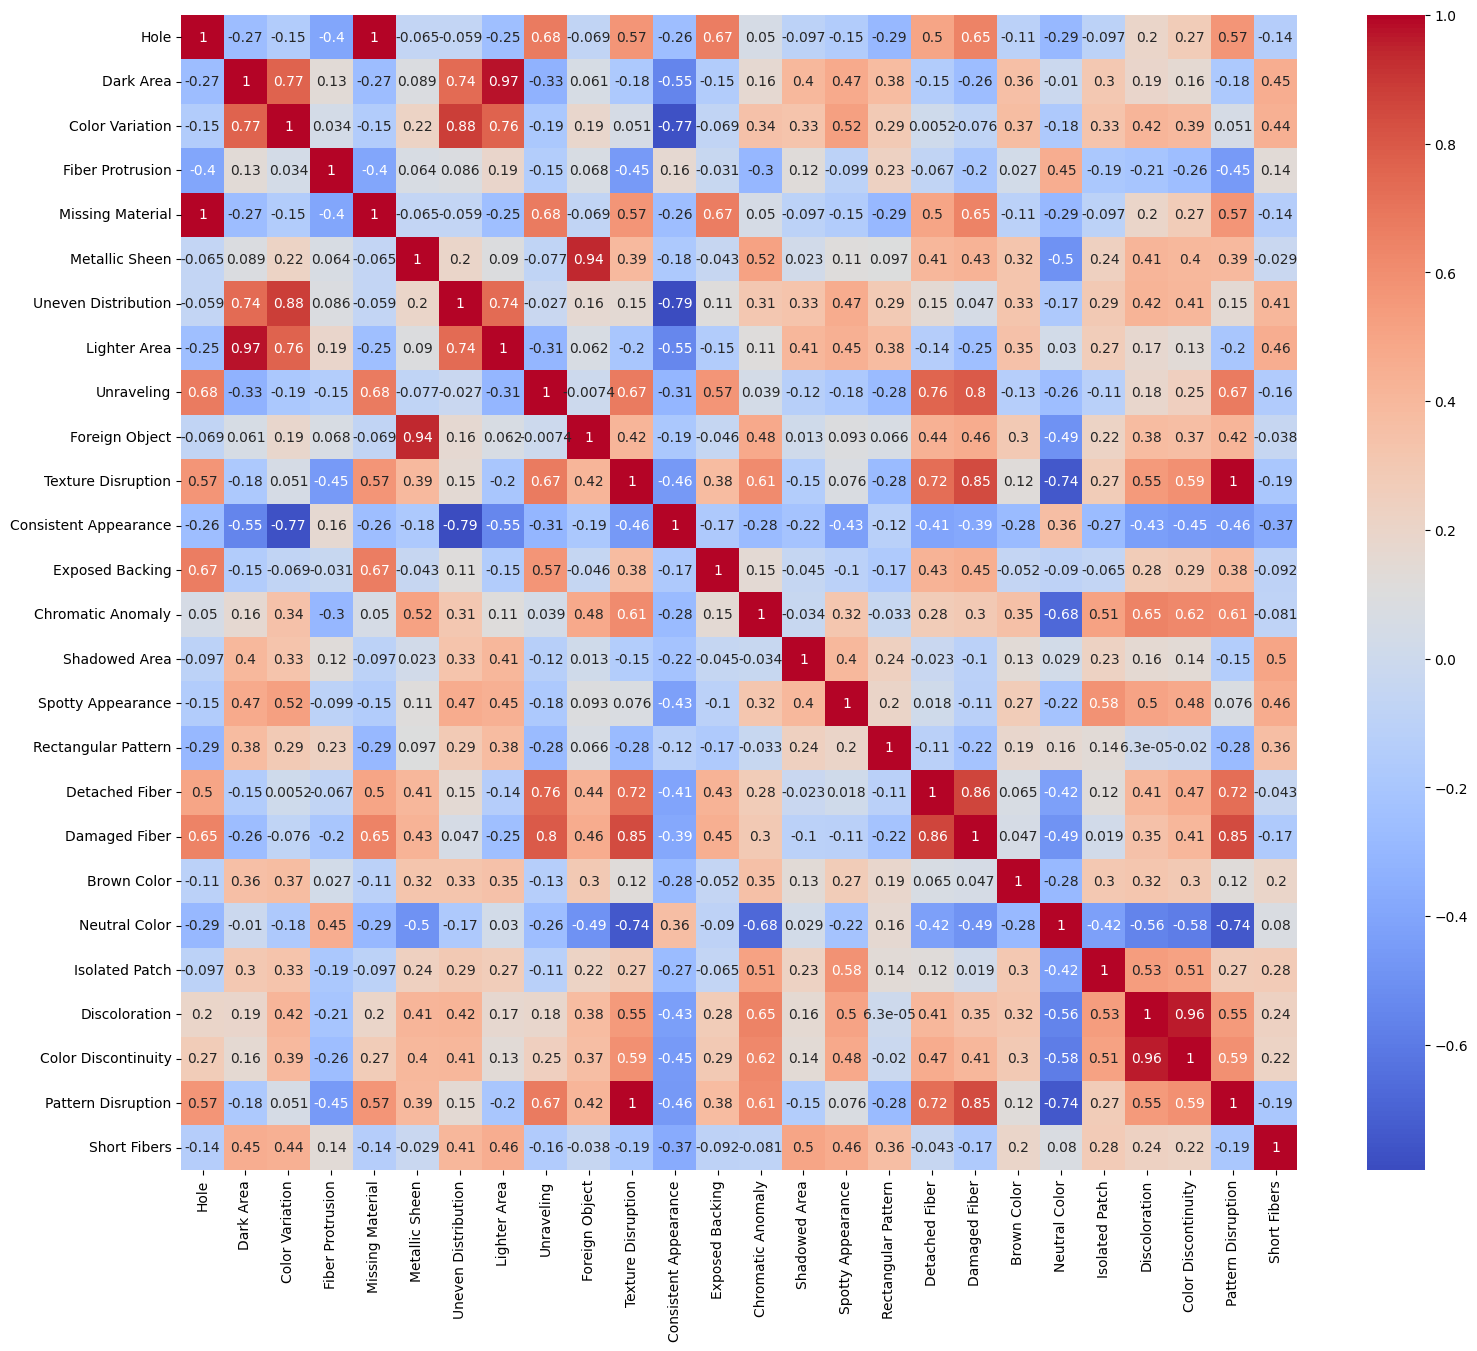

In [47]:
#compute correlation and drop those that are highly correlated
correlation_matrix = final_carpet_df[final_carpet_concepts].corr()

plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.show()

In [ ]:
highly_corr_concepts = ["Embedded Object", "Torn Appearance", "Void", "Irregular Shape", "Fiber Strands", "Short Fibers"]
final_carpet_df = final_carpet_df.drop(columns = highly_corr_concepts)

In [23]:
#automatically exclude anomalous concepts
anomalous_concepts = ['Dark Area', 'Color Variation', 'Hole', 'Missing Material', 'Metallic Sheen', 'Unraveling', 'Foreign Object', 'Texture Disruption', 'Damaged Fiber', 'Pattern Disruption']
normal_concepts = ['Consistent Appearance']

final_carpet_df.loc[final_carpet_df["label_index"] == 0, anomalous_concepts] = 0
final_carpet_df.loc[final_carpet_df["label_index"] == 0, normal_concepts] = 1

In [6]:
final_carpet_concepts = ['Hole', 'Dark Area', 'Color Variation', 'Fiber Protrusion', 'Missing Material', 'Metallic Sheen', 'Uneven Distribution', 'Lighter Area', 'Unraveling', 'Foreign Object', 'Texture Disruption', 'Consistent Appearance', 'Exposed Backing', 'Chromatic Anomaly', 'Shadowed Area', 'Spotty Appearance', 'Rectangular Pattern', 'Detached Fiber', 'Damaged Fiber', 'Brown Color', 'Neutral Color', 'Isolated Patch', 'Discoloration', 'Color Discontinuity', 'Pattern Disruption']

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image as PILImage
import ipywidgets as widgets
import os


# --- Define editable features ---
editable_columns = [col for col in final_carpet_df.columns if col not in ["image_path", "split", "label", "mask_path", "path"]]


def show_image(index):
    print(f"Rendering index {index}")
    row = final_carpet_df.iloc[index]

    img = PILImage.open(row["image_path"])
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {row['label_index']}")
    plt.show()

    # Create input widgets for each editable feature
    editors = {}
    for col in editable_columns:
        value = row[col]
        if isinstance(value, (int, float)):
            editor = widgets.FloatText(value=value, description=col)
        else:
            editor = widgets.Text(value=str(value), description=col)
        editors[col] = editor

    # Button to save edits
    save_button = widgets.Button(description="Save Changes", button_style='success')

    def save_changes(b):
        for col, widget in editors.items():
            final_carpet_df.at[index, col] = widget.value
        print(f"✅ Changes saved for index {index}")

    save_button.on_click(save_changes)

    # Display form
    display(widgets.VBox(list(editors.values()) + [save_button]))


# Interface to scroll through samples
widgets.interact(show_image, index=widgets.IntSlider(min=0, max=len(final_carpet_df)-1, step=1))

interactive(children=(IntSlider(value=0, description='index', max=396), Output()), _dom_classes=('widget-inter…

<function __main__.show_image(index)>

In [5]:
final_carpet_df.to_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/carpet_dataset.csv", index = False)

## Final adjustments

In [10]:
final_carpet_df

,image_path,label_index,mask_path,Hole,Dark Area,Color Variation,Fiber Protrusion,Missing Material,Metallic Sheen,Uneven Distribution,...,Rectangular Pattern,Detached Fiber,Damaged Fiber,Brown Color,Neutral Color,Isolated Patch,Discoloration,Color Discontinuity,Pattern Disruption,Short Fibers
0,/mnt/disk1/borsattifr/datasets/mvtec/carpet/tr...,0,NaN,0,0,0,1,0,0,1,...,1,1,0,0,1,0,0,0,0,0
1,/mnt/disk1/borsattifr/datasets/mvtec/carpet/tr...,0,NaN,0,0,0,1,0,0,1,...,1,0,0,0,1,0,1,1,0,1
2,/mnt/disk1/borsattifr/datasets/mvtec/carpet/tr...,0,NaN,0,0,0,1,0,0,1,...,1,0,0,0,1,0,0,0,0,0
3,/mnt/disk1/borsattifr/datasets/mvtec/carpet/tr...,0,NaN,0,0,0,1,0,0,1,...,1,0,0,1,1,0,0,0,0,1
4,/mnt/disk1/borsattifr/datasets/mvtec/carpet/tr...,0,NaN,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392,/mnt/disk1/borsattifr/datasets/mvtec/carpet/te...,1,/mnt/disk1/borsattifr/datasets/mvtec/carpet/gr...,0,0,1,1,0,0,1,...,1,1,1,0,1,0,1,1,1,0
393,/mnt/disk1/borsattifr/datasets/mvtec/carpet/te...,1,/mnt/disk1/borsattifr/datasets/mvtec/carpet/gr...,0,0,0,1,0,0,0,...,0,1,1,0,0,0,0,0,1,0
394,/mnt/disk1/borsattifr/datasets/mvtec/carpet/te...,1,/mnt/disk1/borsattifr/datasets/mvtec/carpet/gr...,0,0,0,1,0,0,1,...,0,1,1,0,1,0,1,1,1,0
395,/mnt/disk1/borsattifr/datasets/mvtec/carpet/te...,1,/mnt/disk1/borsattifr/datasets/mvtec/carpet/gr...,0,0,0,1,0,0,0,...,0,1,1,0,0,0,0,0,1,0


In [13]:
final_carpet_df = final_carpet_df.drop(columns = ["path", "split", "label"])

KeyError: "['path', 'label'] not found in axis"

### Split into training, test and validation

In [11]:
from sklearn.model_selection import train_test_split

train_df, val_test_df = train_test_split(final_carpet_df, test_size=0.1, stratify=final_carpet_df["label_index"], shuffle = True)

val_df, test_df = train_test_split(val_test_df, test_size=0.5, stratify = val_test_df["label_index"], shuffle = True)

train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

final_carpet_df = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)